<a href="https://colab.research.google.com/github/prishabobde/CS_181_ComputerVision/blob/main/CS181_HW6_B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Effect of Normalization on Homography Estimation
- implementing Direct Linear Transform alg for


In [ ]:
import numpy as np
import cv2
from google.colab import files
import matplotlib.pyplot as plt


In [ ]:
uploaded = files.upload()

for name, data in uploaded.items(): #saving to disk
    with open(name, "wb") as f:
        f.write(data)

image1 = cv2.imread("hw6_image01.png")
image2 = cv2.imread("hw6_image02.png")

Saving hw6_image01.png to hw6_image01.png
Saving hw6_image02.png to hw6_image02.png


## a) H_DLT using unormalized DLT alg

In [ ]:
# Homography computation: manual SVD + OpenCV

# Example corresponding points (x, y) in image1 and (x’, y’) in image2
# Each row: [x, y]
pts1 = np.array([
[457, 260],
[543, 262],
[547, 364],
[455, 363],
[349, 452],
[386, 453],
[617, 453],
[652, 451]
], dtype=float)
pts2 = np.array([
[1832, 1027],
[2181, 1059],
[2164, 1440],
[1822, 1448],
[1396, 1798],
[1555, 1821],
[2469, 1826],
[2614, 1794]
], dtype=float)

# 1. Manual DLT computation using SVD

A = []
for (x, y), (xp, yp) in zip(pts1, pts2):
  A.append([x, y, 1, 0, 0, 0, -xp*x, -xp*y, -xp])
  A.append([0, 0, 0, x, y, 1, -yp*x, -yp*y, -yp])
A = np.array(A)
# Solve Ah = 0 using SVD
U, S, Vt = np.linalg.svd(A)
h = Vt[-1, :] # last row of Vt → last column of V
H = h.reshape(3, 3)
H /= H[-1, -1] # normalize (set h33 = 1)
H_DLT = H
print("Estimated Homography (manual SVD):\n", H)

# 2. Verification using OpenCV

H_cv, mask = cv2.findHomography(pts1, pts2)
print("\nHomography from OpenCV:\n", H_cv)

Estimated Homography (manual SVD):
 [[-1.12376167e-01 -1.69070726e+00  1.42360473e+03]
 [-1.25014736e+00  5.41362432e-01  9.72333716e+02]
 [-7.11756902e-04 -7.05476528e-04  1.00000000e+00]]

Homography from OpenCV:
 [[ 3.59662797e+00 -3.26275433e-01  1.77198085e+02]
 [-3.56198470e-02  3.50280645e+00  8.76307909e+01]
 [-2.72734074e-05 -1.59448080e-04  1.00000000e+00]]


## b) H_DLT using normalized alg
Normalizing each point by
- translating centroid to the origin
- scaling so that the avg distance to the origin is sqrt(2)
- H_norm = resulting homography

In [ ]:
def normalized(pts):
  center = np.mean(pts, axis=0)
  #shift to orig
  pts_translated = pts - center

  #avg distance to orig = sqrt(2)
  distances = np.sqrt(np.sum(pts_translated**2, axis=1))
  mean_distances = np.mean(distances)

  s = np.sqrt(2) / mean_distances
  x_bar = center[0]
  y_bar = center[1]

  #forming similarity transforms
  T = np.array([
      [s, 0, -s*x_bar],
      [0, s, -s*y_bar],
      [0, 0, 1]
  ])

  #converting to homogenous
  homogenous_pts = np.hstack([pts, np.ones((pts.shape[0], 1))])
  pts_norm = (T @ homogenous_pts.T).T[:, :2]

  return pts_norm, T

In [ ]:
pts1_normalized, T1 = normalized(pts1)
pts2_normalized, T2 = normalized(pts2)

A = []
for (x, y), (xp, yp) in zip(pts1_normalized, pts2_normalized):
  A.append([x, y, 1, 0, 0, 0, -xp*x, -xp*y, -xp])
  A.append([0, 0, 0, x, y, 1, -yp*x, -yp*y, -yp])
A = np.array(A)
# Solve Ah = 0 using SVD
U, S, Vt = np.linalg.svd(A)
h = Vt[-1, :] # last row of Vt → last column of V
H_n = h.reshape(3, 3)
# H /= H[-1, -1] # normalize (set h33 = 1)
#denormalize
Hnorm = np.linalg.inv(T2) @ H_n @ T1
Hnorm /= Hnorm[2,2]
print("Estimated Homography (manual SVD):\n", H)
# ---------------------------------------------
# 2. Verification using OpenCV
# ---------------------------------------------
H_n_cv, mask = cv2.findHomography(pts1_normalized, pts2_normalized)
print("\nHomography from OpenCV:\n", H_n_cv)


Estimated Homography (manual SVD):
 [[ 0.99081251 -0.00253453 -0.00402588]
 [ 0.0015817   1.01543357 -0.01176761]
 [-0.00284263 -0.01351476  1.        ]]

Homography from OpenCV:
 [[ 0.98961628 -0.00182175 -0.00355603]
 [ 0.00163063  1.01534716 -0.01272704]
 [-0.00250265 -0.01463111  1.        ]]


## c) Using homography to project test points from image 1 --> image 2


In [ ]:
#putting onto image 2
testPts_one = np.array([[673,262],
                       [500,77]], dtype=float)




In [ ]:
#predicted coordinates in image 2 using H_dlt and H_norm
def proj(H, pts):
  homogenous_pts = np.hstack([pts, np.ones((pts.shape[0], 1))]) #remove? depends on what we pass in
  proj = (H @ homogenous_pts.T).T
  proj = proj[:, :2] / proj[:, 2][:, None]
  return proj


In [ ]:
pred_DLT = proj(H_DLT, testPts_one)
pred_H_n = proj(Hnorm, testPts_one)

print("Predicted (unnormalized):\n", pred_DLT)
print("\nPredicted (normalized):\n", pred_H_n)


Predicted (unnormalized):
 [[-149.56339736  -59.96833608]
 [-338.73053048  -54.01516654]]

Predicted (normalized):
 [[2675.46093636 1043.34647787]
 [2002.94135464  344.27450939]]


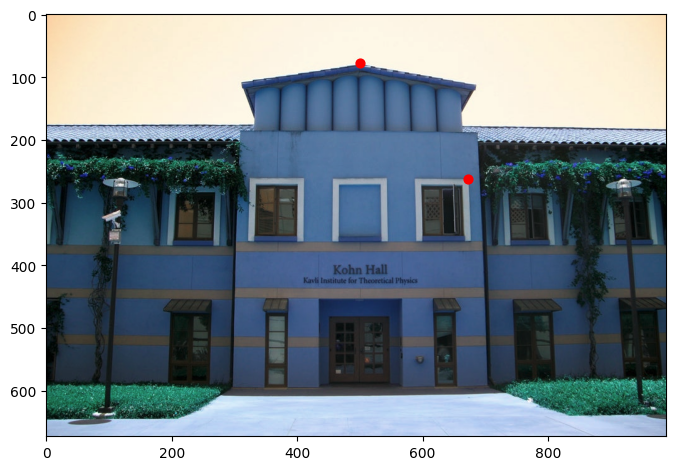

In [ ]:
#image 1 - test points
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image1)

ax.scatter(
    testPts_one[:, 0], testPts_one[:, 1],
    c="red", s=40
)


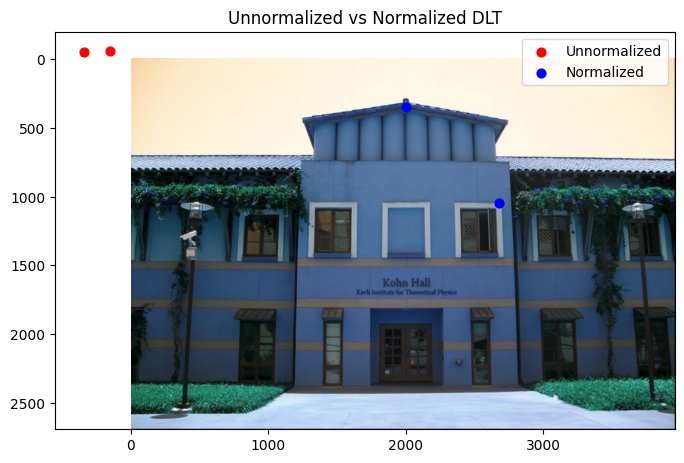

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# Show the base image
ax.imshow(image2)
ax.set_title("Unnormalized vs Normalized DLT")

# Unnormalized predictions (red)
pred_DLT = np.array(pred_DLT)
ax.scatter(
    pred_DLT[:, 0], pred_DLT[:, 1],
    c="red", s=40, label="Unnormalized"
)

# Normalized predictions (blue)
pred_H_n = np.array(pred_H_n)
ax.scatter(
    pred_H_n[:, 0], pred_H_n[:, 1],
    c="blue", s=40, label="Normalized"
)

ax.legend(loc="upper right")
plt.show()
